# 10. A RIEGL project, end to end

This notebook runs the whole Sylva chain on one real plot, straight from the
scanner's files: a RiSCAN PRO project of the TERN Litchfield Savanna
SuperSite core hectare, scanned in July 2021 with a RIEGL VZ-2000i from 64
positions (36 on a 20 m grid inside the plot, 28 on a ring around it).

| Step | Sylva | Output |
|---|---|---|
| 1. Project | `read_riscan_project` | scan positions, SOPs, scan pattern |
| 2. Read | `io.read_rxp_shots`, `Shots.fill_missing`, `filters.voxel_downsample` | 2 cm plot cloud, pulse file with misses |
| 3. Registration check | `ground.classify_ground_csf`, `make_dtm` | vertical offset of every scan |
| 4. Ground | `ground.classify_ground_csf`, `make_dtm`, `normalize_height`, `make_chm` | DTM, CHM, heights |
| 5. Trees | `trees.detect_stems`, `merge_branches`, `segment_trees`, `prune_trees`, `crown_metrics_all` | tree table, segmented cloud |
| 6. Scan quality | `quality.stem_noise` | range noise, per-scan horizontal registration |
| 7. Wood and leaves | `qsm.wood_points`, `build_qsm`, `QSM.metrics`, `leaves.*` | cylinder models, leaf meshes |
| 8. Canopy | `canopy.GapProfile` | PAI, PAVD profile, clumping |
| 9. Voxels | `voxels.ray_voxelize`, `occlusion_profile`, `tree_sampling` | plant area density, what was seen |

It needs RiVLib (see *Point clouds and files*) and about 25 GB of memory.
The first run reads 35 GB from the project and takes 20-30 minutes; the
thinned read is cached in `OUT`, so later runs start at step 3 within a
minute. The data are TERN's.

Step 3 finds that the ring positions are not registered with the inner grid
(metres off in height), so everything after it uses the 36 inner scans. Checking
registration before anything else is the lesson of this plot.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sylva
from sylva import canopy, filters, ground, io, leaves, qsm, quality, trees, voxels

PROJECT = Path("/run/media/tim/EXTERNAL/TERN_TLS_RAW/LSS_2021_07_core.RiSCAN")
OUT = Path.home() / "Data" / "sylva_runs" / PROJECT.stem      # cached read and every product
OUT.mkdir(parents=True, exist_ok=True)

PLOT = (0.0, -100.0, 100.0, 0.0)    # xmin, ymin, xmax, ymax of the core hectare (project frame, m)
BUFFER = 10.0                       # ground is classified this far beyond the plot: a cloth needs both sides
STRIDE = 8                          # keep every 8th pulse when reading
RAY_EVERY = 4                       # ... and every 4th of those for the gap profile and voxels
VOXEL = 0.02                        # point spacing of the plot cloud (m)

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4.5)})
print("sylva", sylva.__version__, "| RiVLib:", io.find_rivlib().name)

sylva 0.1.0 | RiVLib: libscanifc-mt.so


## 1. The project

`read_riscan_project` parses `project.rsp`: every scan position with its
`.rxp`, its SOP (scanner to project transform) and the angular scan
pattern. Nothing is read from the scans yet.

LSS_2021_07_core: 66 positions, 64 with a scan and a SOP; VZ-2000i
zenith 30-130 deg in 3311 lines, 12001 azimuth steps: 40 M pulses per scan; tilt up to 3.8 deg


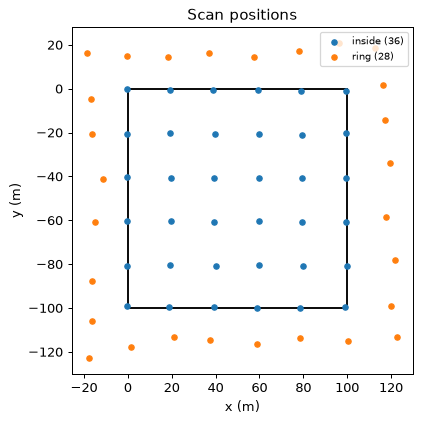

In [2]:
project = sylva.read_riscan_project(PROJECT)
positions = project.with_scans()
origins = np.array([p.sop[:3, 3] for p in positions])
tilt = np.array([np.degrees(np.arccos(p.sop[2, 2])) for p in positions])
pat = positions[0].pattern
print(f"{project.name}: {len(project)} positions, {len(positions)} with a scan and a SOP; {positions[0].instrument}")
print(f"zenith {pat['theta_start']:.0f}-{pat['theta_start'] + pat['theta_delta'] * pat['theta_count']:.0f} deg "
      f"in {pat['theta_count']} lines, {pat['phi_count']} azimuth steps: "
      f"{pat['theta_count'] * pat['phi_count'] / 1e6:.0f} M pulses per scan; tilt up to {tilt.max():.1f} deg")

in_plot = ((origins[:, 0] >= PLOT[0] - 1) & (origins[:, 0] <= PLOT[2] + 1)
           & (origins[:, 1] >= PLOT[1] - 1) & (origins[:, 1] <= PLOT[3] + 1))
fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(plt.Rectangle(PLOT[:2], PLOT[2] - PLOT[0], PLOT[3] - PLOT[1], fill=False, lw=1.5))
ax.scatter(*origins[in_plot, :2].T, c="C0", s=18, label=f"inside ({in_plot.sum()})")
ax.scatter(*origins[~in_plot, :2].T, c="C1", s=18, label=f"ring ({(~in_plot).sum()})")
ax.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title="Scan positions")
ax.legend(loc="upper right", fontsize=8);

## 2. One pass over the scans

Reading a scan is limited by the disk (about 8 s per 0.6 GB scan, whatever
the thinning), so every scan is read once, as pulses, and everything is
derived from that read:

- `shot_stride=STRIDE` keeps every 8th pulse with all its echoes.
- **Points.** The pulses' echoes, moved into the project frame with the
  SOP, cropped to the plot plus `BUFFER` and thinned to 2 cm.
- **Pulses for the canopy.** Every `RAY_EVERY`-th pulse. RiVLib only
  streams pulses that returned something, so the pulses that went to the
  sky are added back with `fill_missing`. Without them the free space above
  the canopy looks unsampled and plant area is overestimated, more and more
  with height. The number fired per zenith line is counted on the downward
  lines (100-125 deg), where every pulse hits the ground. This has to happen
  in the scanner frame, before the SOP.

Only the attributes used later are kept, which keeps the pass under about
25 GB.

In [3]:
cloud_path, rays_path, counts_path = OUT / "cloud_2cm.laz", OUT / "rays.parquet", OUT / "ray_counts.npy"
lo = np.array([PLOT[0] - BUFFER, PLOT[1] - BUFFER, -np.inf])
hi = np.array([PLOT[2] + BUFFER, PLOT[3] + BUFFER, np.inf])


def fired_per_line(s, pattern):
    """Median pulses per zenith line on the downward lines, where every pulse returns."""
    theta, edges = s._zenith_lines(pattern)
    observed, _ = np.histogram(s.zenith_azimuth()[0], bins=edges)
    return int(round(np.median(observed[(theta >= 100) & (theta <= 125)])))


if not (cloud_path.exists() and rays_path.exists() and counts_path.exists()):
    t0 = time.time()
    parts, rays = [], []
    for i, pos in enumerate(positions):
        s = io.read_rxp_shots(pos.rxp, shot_stride=STRIDE)            # scanner frame
        r = s.subset(np.arange(s.n_shots) % RAY_EVERY == 0)
        r = r.fill_missing(pos.pattern, pulses_per_line=fired_per_line(r, pos.pattern))
        r = r.transform(pos.sop)
        r.echo_attrs = {}
        rays.append(r)
        pts = s.transform(pos.sop).to_pointcloud()
        pts = pts[np.all((pts.xyz >= lo) & (pts.xyz <= hi), axis=1)]
        pts = sylva.PointCloud(pts.xyz, {"reflectance": pts.attrs["reflectance"]})
        pts = filters.voxel_downsample(pts, VOXEL)
        parts.append(pts.with_attrs(scan_id=np.full(len(pts), i, np.int32)))
        if i % 16 == 0:
            print(f"{i:2d} {pos.name}: {len(pts):,} points, {r.n_shots:,} pulses ({time.time() - t0:.0f} s)")
    cloud = filters.voxel_downsample(sylva.PointCloud.concatenate(parts), VOXEL)
    del parts
    sylva.write(cloud, cloud_path)
    np.save(counts_path, np.array([r.n_shots for r in rays]))
    shots = sylva.Shots.concatenate(rays)
    del rays
    shots.save(rays_path)
    print(f"read {len(positions)} scans in {time.time() - t0:.0f} s")
else:
    cloud = sylva.read(cloud_path)
    shots = sylva.Shots.load(rays_path)
ray_counts = np.load(counts_path)
print(f"plot cloud: {len(cloud):,} points at {VOXEL * 100:.0f} cm; pulses: {shots.n_shots:,} "
      f"({(shots.echo_count == 0).mean():.0%} misses), {shots.n_echoes:,} echoes")

plot cloud: 112,165,249 points at 2 cm; pulses: 80,575,741 (25% misses), 77,848,847 echoes


## 3. Checking the registration

The scans are only as good as their SOPs. Stem noise (step 6) measures
horizontal registration, but only for scans that see many stems. For
height, every scan can be checked against the ground: build a reference DTM
from the 36 inner-grid scans, then take, for each scan, the lowest point in
each 0.5 m cell within 25 m of it and its median height above the
reference. A scan registered with the others sits a few centimetres above
(grass and litter); one that is not stands out.

46 s; inner scans +0.01 to +0.09 m, ring scans -2.72 to +2.86 m
ring scans more than 0.5 m off: ScanPos037, ScanPos040, ScanPos046, ScanPos053, ScanPos054, ScanPos055, ScanPos056, ScanPos057, ScanPos061, ScanPos062, ScanPos063, ScanPos064, ScanPos065, ScanPos066


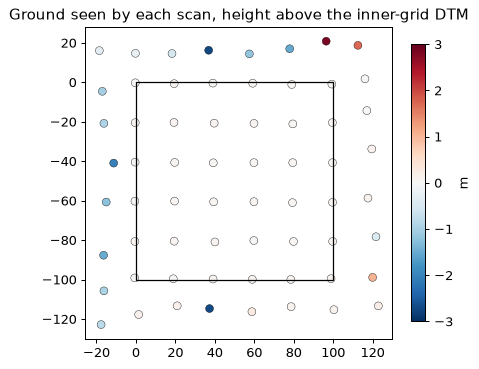

In [4]:
t0 = time.time()
c5 = filters.voxel_downsample(cloud, 0.05)
sid = c5.attrs["scan_id"]
g = ground.classify_ground_csf(c5[in_plot[sid]], cloth_resolution=0.5, rigidness=2)
ref = ground.make_dtm(g, resolution=0.5, bounds=(lo[0], lo[1], hi[0], hi[1]))
del g
dz = np.full(len(positions), np.nan)
for i in range(len(positions)):
    s = c5[sid == i]
    r = np.hypot(s.x - origins[i, 0], s.y - origins[i, 1])
    s = s[(r > 2) & (r < 25)]
    if len(s) < 1000:
        continue
    key = np.floor(s.xyz[:, :2] / 0.5).astype(np.int64)
    k = key[:, 0] * 1_000_000 + key[:, 1]
    order = np.lexsort((s.z, k))
    low = s.xyz[order][np.r_[True, k[order][1:] != k[order][:-1]]]      # lowest point per cell
    dz[i] = np.median(low[:, 2] - ref.sample(low[:, 0], low[:, 1]))
del c5
print(f"{time.time() - t0:.0f} s; inner scans {np.nanmin(dz[in_plot]):+.2f} to {np.nanmax(dz[in_plot]):+.2f} m, "
      f"ring scans {np.nanmin(dz[~in_plot]):+.2f} to {np.nanmax(dz[~in_plot]):+.2f} m")
off = pd.DataFrame({"scan": [p.name for p in positions], "dz_m": dz.round(2)})[~in_plot]
print("ring scans more than 0.5 m off:", ", ".join(off[off.dz_m.abs() > 0.5].scan))

fig, ax = plt.subplots(figsize=(5.5, 5))
sc_ = ax.scatter(*origins[:, :2].T, c=dz, cmap="RdBu_r", vmin=-3, vmax=3, s=40, edgecolor="k", lw=0.3)
ax.add_patch(plt.Rectangle(PLOT[:2], 100, 100, fill=False, lw=1))
ax.set(aspect="equal", title="Ground seen by each scan, height above the inner-grid DTM")
fig.colorbar(sc_, ax=ax, label="m", shrink=0.8);

The 36 inner scans agree to within 10 cm. Most of the ring positions do
not: several put the ground 1-3 m above or below it. Their SOPs look like
the scanner's own GNSS fix (the project gives 0.8 m horizontal and 1.3 m
vertical accuracy for them), not a registration to the inner grid. So from
here on only the inner scans are used, and the ring is dropped from both the
points and the pulses. With the ring included, the DTM steps down by metres
in wedges behind the misregistered positions, and ghost stems appear at the
plot edge. If the ring matters for your plot, register it first.

In [5]:
use = in_plot.copy()
cloud = cloud[use[cloud.attrs["scan_id"]]]
start = np.r_[0, np.cumsum(ray_counts)]
keep = np.zeros(shots.n_shots, bool)
for i in np.flatnonzero(use):
    keep[start[i]:start[i + 1]] = True
shots = shots.subset(keep)
used_counts = ray_counts[use]
rays_path = OUT / "rays_inner.parquet"
shots.save(rays_path)
print(f"{use.sum()} scans kept: {len(cloud):,} points, {shots.n_shots:,} pulses")

36 scans kept: 94,445,009 points, 45,341,712 pulses


## 4. Ground and heights

The cloth simulation filter runs on a 5 cm copy of the plot and its buffer,
and the DTM covers the same area, so the plot edge is not a cloth edge.
Heights are then added to the full 2 cm cloud and the plot is cut out.

A CHM takes the highest point in each cell, and 36 scans collect a few
returns far above the canopy (birds, insects, mixed-pixel ghosts), up to
90 m here. Isolated points are removed before the CHM is built.

The CHM counts a 0.5 m cell as canopy if any point lies above the threshold,
so its "cover" is crown extent, gaps within crowns included. In this open
eucalypt forest that is more than half the plot, while only about a third
of the pulses going up at 30 deg are stopped (step 8). The two answer different
questions.

highest point 93 m, after removing isolated points 23 m
70,189,817 points in the plot; terrain -2.8 to 17.1 m; CHM cells with anything above 5 m: 57%; 56 s


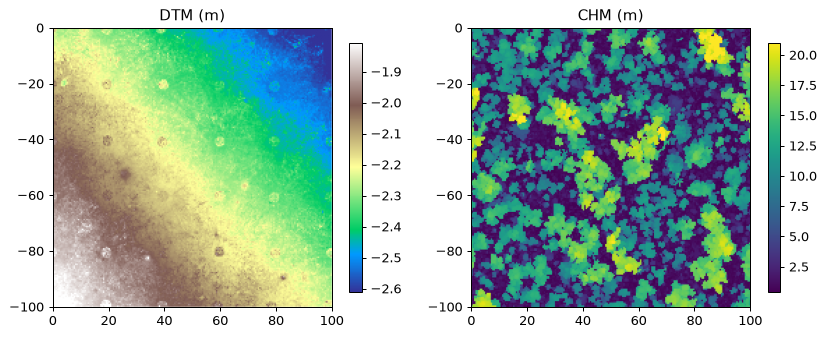

In [6]:
t0 = time.time()
g = ground.classify_ground_csf(filters.voxel_downsample(cloud, 0.05), cloth_resolution=0.5, rigidness=2)
dtm = ground.make_dtm(g, resolution=0.5, bounds=(lo[0], lo[1], hi[0], hi[1]))
del g
cloud = ground.normalize_height(cloud, dtm)
inside = ((cloud.x >= PLOT[0]) & (cloud.x <= PLOT[2]) & (cloud.y >= PLOT[1]) & (cloud.y <= PLOT[3]))
plot = cloud[inside]
del cloud
# A CHM takes the highest point per cell, so one stray return (a bird, a ghost) sets a cell:
# drop isolated points first.
tops = filters.voxel_downsample(plot, 0.05)
tops = filters.radius_outlier_removal(tops, radius=0.25, min_neighbors=5)
chm = ground.make_chm(tops, resolution=0.5, bounds=PLOT)
print(f"highest point {plot.attrs['height'].max():.0f} m, after removing isolated points {tops.attrs['height'].max():.0f} m")
del tops
dtm.to_ascii_grid(OUT / "dtm.asc")
chm.to_ascii_grid(OUT / "chm.asc")
print(f"{len(plot):,} points in the plot; terrain {np.nanmin(dtm.data):.1f} to {np.nanmax(dtm.data):.1f} m; "
      f"CHM cells with anything above 5 m: {canopy.canopy_cover(chm.data, 5.0):.0%}; {time.time() - t0:.0f} s")

X, Y = dtm.cell_centers()
dtm_plot = np.where((X >= PLOT[0]) & (X <= PLOT[2]) & (Y >= PLOT[1]) & (Y <= PLOT[3]), dtm.data, np.nan)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, r, title, cmap in [(axes[0], dtm_plot, dtm, "DTM (m)", "terrain"), (axes[1], chm.data, chm, "CHM (m)", "viridis")]:
    lo_, hi_ = np.nanpercentile(data, [1, 99.5])
    im = ax.imshow(data, origin="lower", extent=(r.xmin, r.xmax, r.ymin, r.ymax), cmap=cmap, vmin=lo_, vmax=hi_)
    ax.set(title=title, aspect="equal", xlim=PLOT[::2], ylim=PLOT[1::2])
    fig.colorbar(im, ax=ax, shrink=0.8)

## 5. Trees

Two settings differ from the defaults, both for a plot this size:

- `min_arc_deg=130`. A stem circle must cover 130 degrees of arc
  unbroken. With a scan every 20 m, every real stem is seen from most sides, while
  grass tussocks, termite mounds and shrubs give short arcs. Without it,
  detection returned over 5 000 candidates on this plot, many of them
  1.4 m wide at the diameter limit.
- `voxel_size=0.1` for the merge and segmentation graphs. On 70-76 M
  points the default 5 cm graph took 17 minutes and 38 GB. At 10 cm the
  whole step takes about 3 minutes and 15 GB.

Some stems come out wider than 40 cm yet lower than 8 m: solid, round and
short. On this plot these are most likely termite mounds, or stumps. The
table flags them as `wide_and_short` instead of dropping them; check them
in the segmented cloud before using the table.

In [7]:
t0 = time.time()
cands = trees.detect_stems(plot, min_arc_deg=130)
stems, _ = trees.merge_branches(plot, cands, voxel_size=0.1)
labels = trees.segment_trees(plot, stems, voxel_size=0.1)
trees.tree_heights(plot, labels, stems, percentile=99)
stems, labels = trees.prune_trees(stems, labels, min_height=2.0)
crowns = trees.crown_metrics_all(plot, labels)
table = pd.DataFrame([{**t.as_dict(), **crowns.get(t.tree_id, {})} for t in stems])
table["wide_and_short"] = (table.dbh > 0.4) & (table.height < 8)
table.to_csv(OUT / "trees.csv", index=False)
print(f"{len(cands)} candidates -> {len(stems)} trees in {time.time() - t0:.0f} s; "
      f"{table.wide_and_short.sum()} are wider than 40 cm but lower than 8 m")
table[["dbh", "height", "crown_area", "crown_base_height", "quality"]].describe().round(2)

792 candidates -> 625 trees in 157 s; 12 are wider than 40 cm but lower than 8 m


,dbh,height,crown_area,crown_base_height,quality
count,625.00,625.00,625.00,625.00,625.00
mean,0.12,9.47,10.07,4.46,0.47
std,0.10,3.62,15.77,2.80,0.11
min,0.04,2.15,0.11,0.50,0.13
25%,0.07,7.12,2.80,2.00,0.44
50%,0.09,9.09,4.47,4.00,0.52
75%,0.12,11.24,8.67,6.50,0.54
max,0.93,22.19,118.25,13.50,0.60


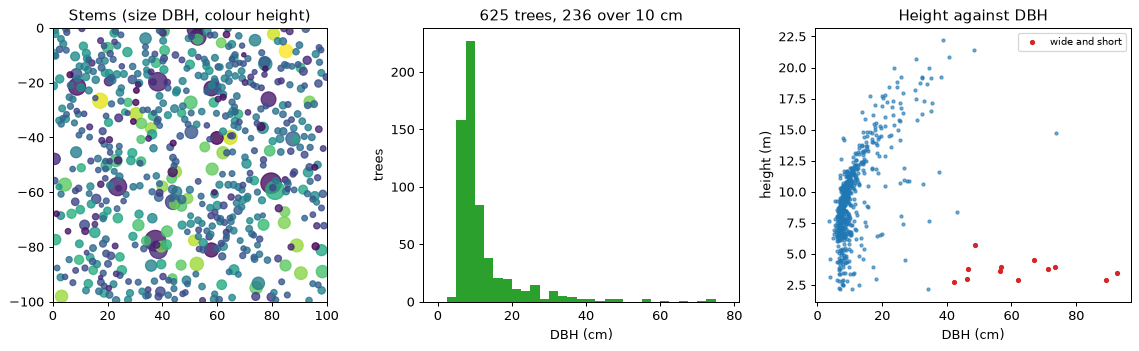

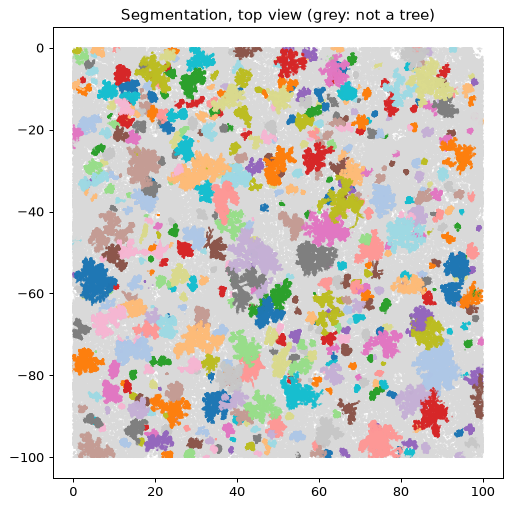

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(table.x, table.y, s=table.dbh * 300, c=table.height, cmap="viridis", alpha=0.8)
axes[0].set(aspect="equal", title="Stems (size DBH, colour height)", xlim=PLOT[::2], ylim=PLOT[1::2])
axes[1].hist(table.dbh * 100, bins=np.arange(0, 80, 2.5), color="C2")
axes[1].set(xlabel="DBH (cm)", ylabel="trees", title=f"{len(table)} trees, {(table.dbh >= 0.1).sum()} over 10 cm")
w = table.wide_and_short
axes[2].scatter(table.dbh[~w] * 100, table.height[~w], s=6, alpha=0.6)
axes[2].scatter(table.dbh[w] * 100, table.height[w], s=10, color="C3", label="wide and short")
axes[2].set(xlabel="DBH (cm)", ylabel="height (m)", title="Height against DBH")
axes[2].legend(fontsize=8)
fig.tight_layout()

sub = np.random.default_rng(0).choice(len(plot), 2_000_000, replace=False)
lab = labels[sub]
cols = np.where(lab[:, None] >= 0, plt.cm.tab20(lab % 20)[:, :3], 0.85)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
order = np.argsort(plot.attrs["height"][sub])
ax.scatter(plot.x[sub][order], plot.y[sub][order], c=cols[order], s=0.05)
ax.set(aspect="equal", title="Segmentation, top view (grey: not a tree)");

## 6. Scan quality

Stems between 1 and 3 m are fitted from all scans together, and each point's
radial residual is read per scan: range noise with the stem's shape removed,
and each scan's horizontal offset from where the others put the stem. The
best-supported stems are enough. `summary()` leaves scans that were
measured in no stem slice out of the registration figures and reports how
many were used (`n_scans_registered`).

4 s; {'n_stems': 128, 'n_slices': 733, 'n_scans': 36, 'sigma_total': 7.3, 'sigma_corrected': 6.7, 'sigma_within': 6.0, 'sigma_local': 4.8, 'tail_fraction': 0.029511556033324376, 'n_scans_registered': 36, 'registration_rms': 5.9, 'registration_max': 15.8, 'worst_scan': 35} (sigmas and offsets in mm)


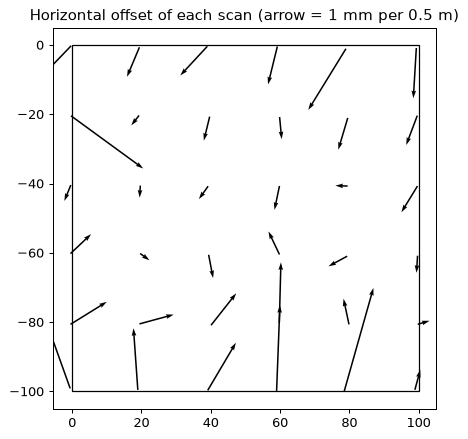

In [9]:
t0 = time.time()
good = [t for t in stems if t.dbh >= 0.1 and t.quality >= np.quantile([s.quality for s in stems], 0.5)]
q = quality.stem_noise(plot, scan_id="scan_id", stems=good)
summary = q.summary()
print(f"{time.time() - t0:.0f} s;", {k: (round(v * 1000, 1) if isinstance(v, float) and k != "tail_fraction" else v)
                                   for k, v in summary.items()}, "(sigmas and offsets in mm)")
sc = pd.DataFrame(q.scans)
sc = sc[sc.n_slices >= 1]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
o = origins[sc.scan]
ax.quiver(o[:, 0], o[:, 1], sc.tx * 1000, sc.ty * 1000, angles="xy", scale_units="xy", scale=0.5, width=0.004)
ax.add_patch(plt.Rectangle(PLOT[:2], 100, 100, fill=False, lw=1))
ax.set(aspect="equal", title="Horizontal offset of each scan (arrow = 1 mm per 0.5 m)");

## 7. Wood models and leaves

For the largest well-supported trees: the wood filter, a cylinder model and
its architecture. `measured_volume_fraction` is the share of the volume
fitted to points rather than filled in by the taper and pipe-model priors,
so read the volumes with it.

In [10]:
t0 = time.time()
for f in list(OUT.glob("qsm_*")) + list(OUT.glob("tree_*.obj")):
    f.unlink()                                          # models of an earlier run
q_med = np.median([t.quality for t in stems])
big = sorted([t for t in stems if t.quality >= q_med and t.height >= 10], key=lambda t: -t.dbh)[:4]  # largest real trees
models, rows = {}, []
for t in big:
    tree = plot[labels == t.tree_id]
    model = qsm.build_qsm(qsm.wood_points(tree), base_xy=(t.x, t.y))
    model.to_csv(OUT / f"qsm_{t.tree_id:04d}.csv")
    model.to_ply(OUT / f"qsm_{t.tree_id:04d}.ply")
    m = model.metrics()
    models[t.tree_id] = (tree, model)
    rows.append({"tree_id": t.tree_id, "dbh_stem": t.dbh, "dbh_qsm": m["dbh"], "height": m["height"],
                 "volume_m3": m["total_volume"], "measured_volume": m["measured_volume_fraction"],
                 "max_order": m["max_order"], "insertion_deg": m["median_insertion_angle"],
                 "crown_area": m["crown"]["projected_area"]})
print(f"{len(big)} QSMs in {time.time() - t0:.0f} s")
pd.DataFrame(rows).round(3)

4 QSMs in 5 s


,tree_id,dbh_stem,dbh_qsm,height,volume_m3,measured_volume,max_order,insertion_deg,crown_area
0,11,0.483,0.477,21.467,2.584,0.810,6,45.854,65.717
1,16,0.406,0.398,20.680,1.955,0.869,6,53.445,89.702
2,17,0.387,0.385,22.564,1.774,0.786,7,48.884,91.712
3,20,0.355,0.383,17.590,1.343,0.770,7,46.061,79.817


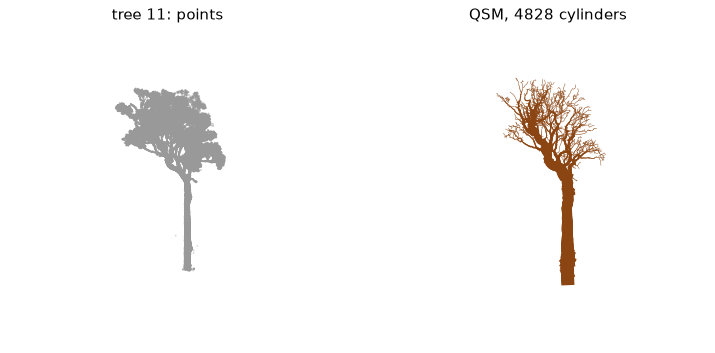

In [11]:
tid = big[0].tree_id
tree, model = models[tid]
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
s = tree[np.random.default_rng(0).choice(len(tree), min(len(tree), 60_000), replace=False)]
ax.scatter(*s.xyz.T, s=0.2, c="0.6")
ax.set_title(f"tree {tid}: points")
ax = fig.add_subplot(1, 2, 2, projection="3d")
for a, b, r in zip(model.start, model.end, model.column("radius")):
    ax.plot(*np.c_[a, b], color="saddlebrown", lw=max(0.3, r * 40))
ax.set_title(f"QSM, {len(model)} cylinders")
for a in fig.axes:
    a.set_box_aspect(np.ptp(tree.xyz, axis=0))
    a.set_axis_off()

In [12]:
wood = leaves.classify_leaf_wood(tree)
foliage = tree[~wood]
angles = leaves.leaf_angle_distribution(foliage)
area = leaves.leaf_area_density(foliage, voxel_size=0.25)
mesh = leaves.add_leaves(model, area, angles, leaf_points=foliage)
leaves.write_tree_obj(OUT / f"tree_{tid:04d}.obj", model, mesh)
print(f"wood {wood.mean():.0%} of points; mean leaf angle {angles.mean_deg:.0f} deg (nearest de Wit: {angles.de_wit}); "
      f"leaf area seen {area.total_area:.1f} m2 as {len(mesh)} leaves -> tree_{tid:04d}.obj")

wood 40% of points; mean leaf angle 57 deg (nearest de Wit: spherical); leaf area seen 199.8 m2 as 111080 leaves -> tree_0011.obj


## 8. Canopy gap profile

Gap probability by zenith ring and height, pooled over the 36 inner scans (Jupp et al. 2009). The VZ-2000i scans from 30 deg zenith down, so
the rings run from 30 to 70 deg. The pulses already hold their misses, so
no fired-pulse count is needed. Heights come from the DTM.

36 scans, 11 s
{'saturated': False, 'gap_57': 0.456, 'pai_hinge': 0.864, 'pai_linear': 0.767, 'pai_weighted': 0.799, 'mla_linear': 70.634, 'clumping': 0.93, 'pai_hinge_corrected': 0.93, 'canopy_height': 20.0, 'closure_57': 0.544, 'cover': 0.354, 'cover_zenith': 32.5, 'n_scans': 36, 'pulses': 17710145.0}


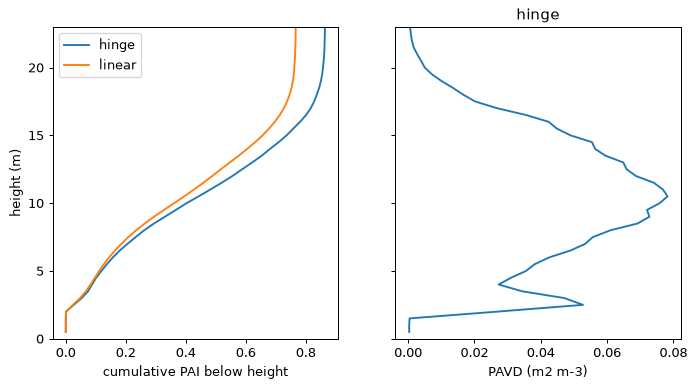

In [13]:
t0 = time.time()
prof = canopy.GapProfile.empty(zenith_edges=np.arange(30.0, 75.0, 5.0))
start = np.r_[0, np.cumsum(used_counts)]
xyz = shots.echo_xyz()
echo_h = xyz[:, 2] - dtm.sample(xyz[:, 0], xyz[:, 1])
del xyz
soe = shots.shot_of_echo()
for j in range(len(used_counts)):
    keep = np.zeros(shots.n_shots, bool)
    keep[start[j]:start[j + 1]] = True
    prof.add_scan(shots.subset(keep), echo_h[keep[soe]])
del soe, echo_h
rep = prof.report()
print(f"{rep['n_scans']} scans, {time.time() - t0:.0f} s")
print({k: round(v, 3) if isinstance(v, float) else v for k, v in rep.items() if np.isscalar(v)})

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)
axes[0].plot(rep["pai_hinge_profile"], rep["height"], label="hinge")
axes[0].plot(rep["pai_linear_profile"], rep["height"], label="linear")
axes[0].set(xlabel="cumulative PAI below height", ylabel="height (m)", ylim=(0, rep["canopy_height"] + 3))
axes[0].legend()
axes[1].plot(rep["pavd_hinge"], rep["height"])
axes[1].set(xlabel="PAVD (m2 m-3)", title="hinge");

## 9. Ray-traced voxels, and what was seen

Every pulse is traced through a 0.5 m grid over the plot. With
`occlusion=True` each voxel is observed (a pulse went through or ended in
it), occluded (only pulses already stopped reached it) or unreached.

- **Beam geometry.** `beam=` weights each pulse by its cross-section in
  the voxel, which grows with range. The values are approximate (7 mm exit,
  0.27 mrad). Only relative sections enter a pooled layer estimate, so they
  matter little: without `beam` the PAI differs by about 3 %.
- **Profile.** Plant area density per height layer is pooled over the layer
  (intercepted section over effective free path), and only layers where the
  median voxel saw at least 50 pulses are counted. With every 32nd pulse,
  that is where the numbers can be trusted.

The voxel PAI comes out at the gap profile's clumping-corrected hinge PAI.
They are independent estimates from the same pulses: one traces every
pulse through the grid, the other counts gaps by zenith ring. Both depend
on the misses being there. Traced without them, the grid gave about twice
the plant area, rising with height.

With 36 positions and the misses traced, a pulse crosses every voxel of this
open canopy, so nothing is occluded or unreached. In denser plots, and with
fewer scans, `occlusion_profile` and `observed_map` show where to rescan. The
right panel shows how many pulses reached each layer, which sets how far up
the profile can be trusted.

RayVoxelGrid(200x200x102 @ 0.5 m) in 22 s; canopy space: {'observed': 1.0, 'occluded': 0.0, 'unobserved': 0.0, 'top': 44.64}
voxel PAI from 0.5 to 30.0 m (sampled layers): 0.93; gap profile hinge PAI 0.86 (clumping-corrected 0.93)


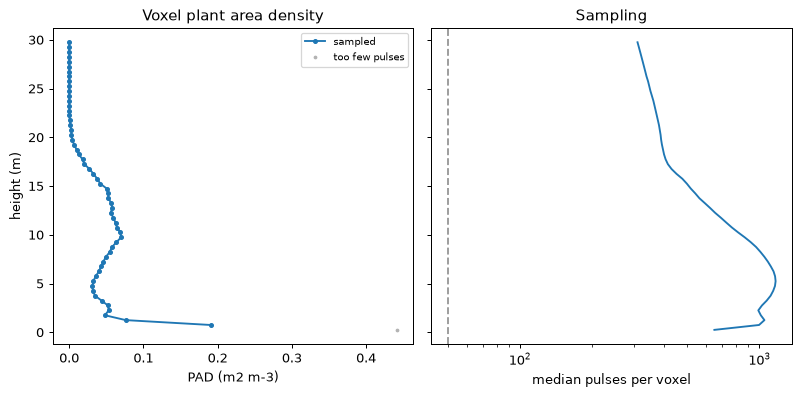

In [14]:
t0 = time.time()
bounds = ((PLOT[0], PLOT[1], float(np.nanmin(dtm.data)) - 1.0), (PLOT[2], PLOT[3], float(np.nanmax(dtm.data)) + 30.0))
grid = voxels.ray_voxelize(rays_path, 0.5, bounds, dtm=dtm, occlusion=True, beam=(0.007, 0.00027))
occ = grid.occlusion_profile(min_height=0.5)
print(f"{grid} in {time.time() - t0:.0f} s; canopy space:",
      {k: round(v, 3) for k, v in occ["total"].items()})

h, beams = grid.distance_from_ground, grid.num_beams
edges = np.arange(0.0, 30.5, 0.5)
k = np.digitize(h, edges) - 1
layer = []
for j in range(len(edges) - 1):
    m = k == j
    bi, be = grid.bs_intercepted[m].sum(), grid.bs_effective_free_path[m].sum()
    layer.append((edges[j], np.median(beams[m]) if m.any() else 0, 2 * bi / be if be > 0 else np.nan))
layer = pd.DataFrame(layer, columns=["height", "median_beams", "pad"])
ok = (layer.median_beams >= 50) & (layer.height >= 0.5)
top = layer.height[ok].max() + 0.5
print(f"voxel PAI from 0.5 to {top:.1f} m (sampled layers): {layer.pad[ok].sum() * 0.5:.2f}; "
      f"gap profile hinge PAI {rep['pai_hinge']:.2f} (clumping-corrected {rep['pai_hinge_corrected']:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)
axes[0].plot(layer.pad.where(ok), layer.height + 0.25, "o-", ms=3, label="sampled")
axes[0].plot(layer.pad.where(~ok), layer.height + 0.25, "o", ms=2, color="0.7", label="too few pulses")
axes[0].set(xlabel="PAD (m2 m-3)", ylabel="height (m)", title="Voxel plant area density")
axes[0].legend(fontsize=8)
axes[1].semilogx(layer.median_beams.clip(lower=1), layer.height + 0.25)
axes[1].axvline(50, color="0.6", ls="--")
axes[1].set(xlabel="median pulses per voxel", title="Sampling")
fig.tight_layout()

Per tree, the voxels show whether the space just above the tree was seen.
Where it was not, the tree may continue where no scan reached, and its
height is a lower bound. Here every tree top was seen, so the heights in the
table are not limited by occlusion. How many pulses reached each crown is
the more telling figure: it sets how well crown shape and leaf area are
known.

0 of 625 trees have less than half of the space above them observed


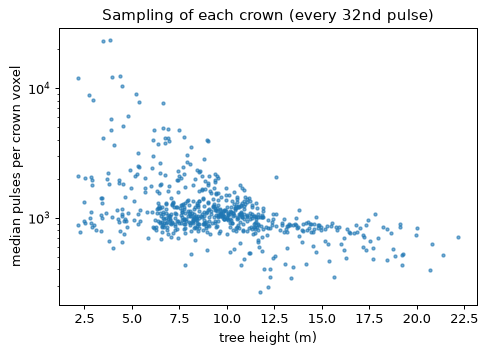

In [15]:
samp = voxels.tree_sampling(grid, plot, labels)
samp = pd.DataFrame({k: v for k, v in samp.items() if np.ndim(v) == 1})     # beams_by_quarter is (trees, 4)
table = table.merge(samp[["tree_id", "above_observed_fraction", "median_beams"]], on="tree_id", how="left")
table.to_csv(OUT / "trees.csv", index=False)
flag = table.above_observed_fraction < 0.5
print(f"{flag.sum()} of {len(table)} trees have less than half of the space above them observed")
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(table.height, table.median_beams, s=6, alpha=0.6)
ax.set(xlabel="tree height (m)", ylabel="median pulses per crown voxel", yscale="log",
       title="Sampling of each crown (every 32nd pulse)");

## Outputs

Everything lands in `OUT`:

In [16]:
sylva.write(plot.with_attrs(tree_id=labels.astype(np.int32)), OUT / "plot_segmented.laz")
for f in sorted(OUT.iterdir()):
    print(f"{f.name:28s} {f.stat().st_size / 1e6:9.1f} MB")

chm.asc                            0.3 MB
cloud_2cm.laz                    814.4 MB
dtm.asc                            0.5 MB
plot_segmented.laz              1004.5 MB
qsm_0011.csv                       0.6 MB
qsm_0011.ply                       5.2 MB
qsm_0016.csv                       0.5 MB
qsm_0016.ply                       4.4 MB
qsm_0017.csv                       0.8 MB
qsm_0017.ply                       7.2 MB
qsm_0020.csv                       0.9 MB
qsm_0020.ply                       8.7 MB
ray_counts.npy                     0.0 MB
rays.parquet                     747.8 MB
rays_inner.parquet               421.9 MB
tree_0011.obj                     36.3 MB
trees.csv                          0.1 MB
